# Getting data into the right format

In order to use `SegTraQ`, you first need to get your data into a `SpatialData` object. While `spatialdata_io` has a lot of readers for different technologies, the constantly evolving landscape of segmentation methods makes it difficult to provide up-to-date, generalizable readers. To facilitate the process of getting your data into the correct format, we provide examples for some segmentation methods.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [90]:
import spatialdata_io  # noqa
import spatialdata_plot # noqa
import segtraq

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import anndata as ad
import tifffile as tiff
import numpy as np
import geopandas as gpd
import spatialdata as sd
import shutil
import gzip
import shapely  
import json

from pathlib import Path
from rasterio.features import shapes
from shapely.geometry import shape
from scipy.sparse import csr_matrix
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

In [2]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")

## Xenium

For Xenium data, we can make use of the functions from `spatialdata_io`. We don't need `cells_as_circles`, `cell_labels`, `nucleus_labels` and `morphology_mip` for `SegTraQ`, so we will not read it. 

In [3]:
sdata_xenium = spatialdata_io.xenium(data_path,
                              cells_as_circles=False,
                              cells_labels=False,
                              nucleus_labels=False,
                              morphology_mip=False)
sdata_xenium

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

For visualization, we crop the `SpatialData` object to zoom into a smaller region. 

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


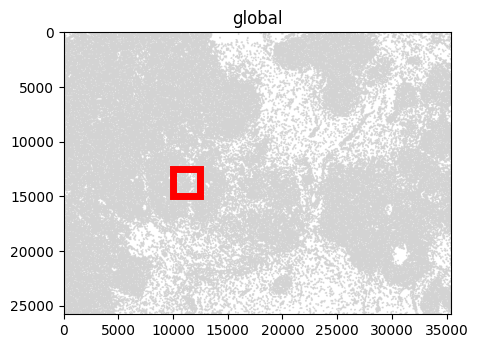

In [7]:
bb_xmin = 10000
bb_ymin = 12500
bb_w = 2500
bb_h = 2500
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

f, ax = plt.subplots(figsize=(5, 5))
sdata_xenium.pl.render_shapes("cell_boundaries").pl.show(ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

Cropping currently suffers from performance issues, and can take tens of minutes on large datasets. This will be improved in future releases of `SpatialData`.

In [14]:
# Link table to spatial element before cropping
sdata_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


In [15]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

sdata_xenium_crop = crop(sdata_xenium)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


The `SpatialData` plot below shows the cell boundaries colored by cell area. Xenium version 1 uses nuclear expansion to generate cell boundaries. 

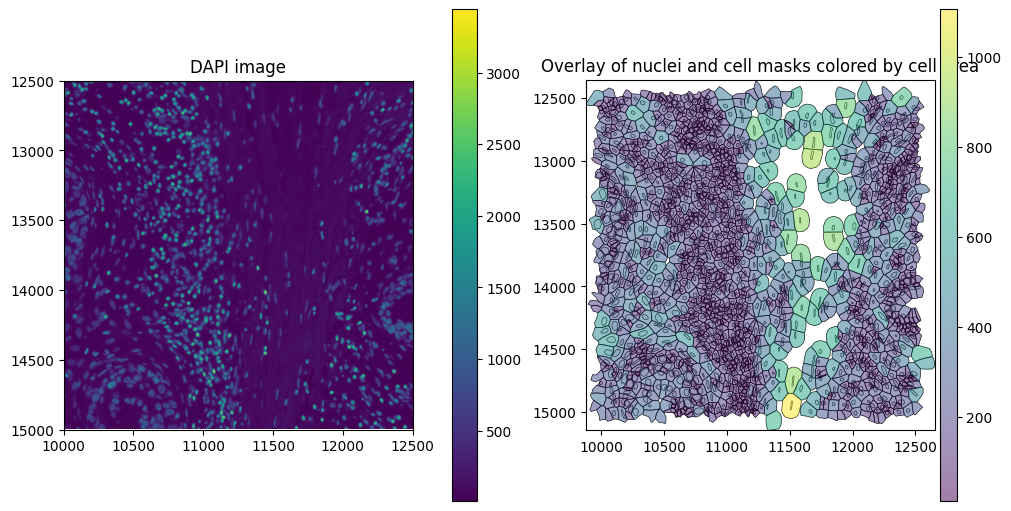

In [17]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_xenium_crop.pl.render_images("morphology_focus").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot overlay of nuclei and cell boundaries colored by cell area
sdata_xenium_crop.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="cell_area",
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by cell area", colorbar=True)

Finally, we can read these into SegTraQ. Don't worry if you do not know all of these parameters up front, you can start by simply passing an `sdata` object into the function and it will tell you exactly which parameters need to be set.

In [ ]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium, 
    shapes_cell_id_key=None, 
    nucleus_shapes_cell_id_key=None, 
    points_background_id=-1 #"UNASSIGNED" for Xenium prime
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [1, 2, 3, 4, 5]..., IDs in tables index: ['156974', '96573', '165531', '24694', '104791']...
  validate_spatialdata(


## BIDCell

Depending on the segmentation method applied to re-segment the Xenium data, the data output format will differ. No `SpatialData` readers are available for individual segmentation methods. Below, we demonstrate how to load data from the output of the segmentation method `BIDCell` into `SpatialData`. 

The single-cell expression and metadata is first loaded into an `AnnData` object.

In [ ]:
csv_files = list(data_path.glob("bidcell_output/cell_gene_matrices/202*/cell*.csv"))
dfs = [pd.read_csv(f) for f in csv_files]
merged_df = pd.concat(dfs, ignore_index=True).sort_values("cell_id").reset_index(drop=True)

merged_df = merged_df.rename(
    columns={
        "cell_size": "cell_area",
        "cell_centroid_x": "x_centroid",
        "cell_centroid_y": "y_centroid",
    }
)

meta_cols = ["cell_id", "x_centroid", "y_centroid", "cell_area"]
expr_cols = [c for c in merged_df.columns if c not in meta_cols]

obs = merged_df[meta_cols].copy()
obs["cell_id"] = obs["cell_id"].astype(np.int32)
obs["region"] = "cell_boundaries"

X = merged_df[expr_cols].to_numpy()
var = pd.DataFrame(index=pd.Index(expr_cols))

adata = ad.AnnData(X=X, obs=obs, var=var)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


`BIDCell` outputs cell and nucleus boundaries as a raster (label image) rather than vector shapes (polygons). Therefore, we first convert the rasterized boundaries into polygon geometries using the function below.
Nucleus boundaries are not copied from Xenium, because BIDCell, re-runs nuclear segmentation internally via Cellpose.

In [ ]:
def labels_to_shapes_fast(label_img: np.ndarray, simplify_tolerance: float | None = 0.5) -> gpd.GeoDataFrame:
    if label_img.ndim != 2:
        raise ValueError("Input label_img must be 2D.")

    # Ensure an integer dtype rasterio is happy with
    lab = np.asarray(label_img)
    lab = lab.astype(np.int32, copy=False)

    # Polygonize all nonzero labels in one pass
    mask = lab != 0

    geoms = []
    ids = []
    for geom_mapping, value in shapes(lab, mask=mask, connectivity=8):
        # value is the label id for that polygon
        ids.append(int(value))
        geoms.append(shape(geom_mapping))

    gdf = gpd.GeoDataFrame({"cell_id": ids, "geometry": geoms}).set_index("cell_id")
    gdf = gdf.dissolve(by="cell_id", as_index=True)
    
    if simplify_tolerance and simplify_tolerance > 0 and not gdf.empty:
        gdf["geometry"] = shapely.simplify(
            gdf.geometry.values, simplify_tolerance, preserve_topology=True
        )
    
    return gdf

In [ ]:
cell_label_files = list(data_path.glob("bidcell_output/model_outputs/202*/test_output/*_connected.tif"))
cell_labels = tiff.imread(cell_label_files[0])

nucleus_labels = tiff.imread(data_path / "bidcell_output/nuclei.tif")

cell_shapes_gdf = labels_to_shapes_fast(cell_labels, simplify_tolerance=0.5)
nucleus_shapes_gdf = labels_to_shapes_fast(nucleus_labels, simplify_tolerance=0.5)

`BIDCell` filters the Xenium transcripts file prior to segmentation by removing low-quality transcripts (qv < 20) and control probes. However, the cell IDs in the processed transcripts file (`transcripts_processed.csv`) still correspond to the original Xenium segmentation. Therefore, we reassign cell IDs based on the BIDCell segmentation masks.

In [ ]:
transcripts_path = data_path / "bidcell_output/transcripts_processed.csv"

transcripts_df = pd.read_csv(transcripts_path, index_col=0)
transcripts_df.rename(columns={"x_location": "x", "y_location": "y", "z_location": "z"}, inplace=True)
x = np.rint(transcripts_df["x"]).astype(int)
y = np.rint(transcripts_df["y"]).astype(int)
transcripts_df["cell_id"] = cell_labels[y, x]
transcripts_df["feature_name"] = transcripts_df["feature_name"].astype("category")

The `SpatialData` object can then be built from the `AnnData` object, the `cell_boundaries`, `nucleus_boundaries` and `transcripts`. We also link the table observations to the shapes by setting the `region_key` and `instance_key`.

In [ ]:
sdata_bidcell = sd.SpatialData(
    points={"transcripts": sd.models.PointsModel.parse(transcripts_df)},
    shapes={"cell_boundaries": sd.models.ShapesModel.parse(cell_shapes_gdf),
            "nucleus_boundaries": sd.models.ShapesModel.parse(nucleus_shapes_gdf)},
    tables={"table": sd.models.TableModel.parse(adata, region_key="region", region="cell_boundaries", instance_key="cell_id")}
)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/models/models.py:1183: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


The `images` can be copied from `sdata_xenium` since it is not changed by BIDCell segmentation. We have to make sure that the individual layers are aligned and hence set transformations in line with the xenium data.

In [ ]:
sdata_bidcell.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_bidcell.shapes["cell_boundaries"], xenium_transformation)
set_transformation(sdata_bidcell.shapes["nucleus_boundaries"], xenium_transformation)
set_transformation(sdata_bidcell.points["transcripts"], xenium_transformation)

We crop the `SpatialData` object as before to visualize the data. 

In [56]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

sdata_bidcell_crop = crop(sdata_bidcell)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


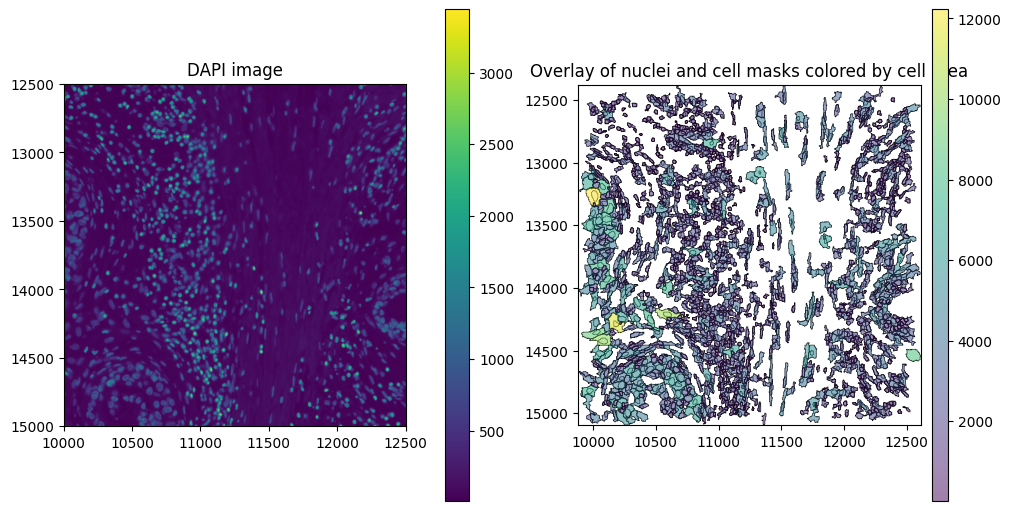

In [57]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_bidcell_crop.pl.render_images("morphology_focus").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot overlay of nuclei and cell boundaries colored by cell area
sdata_bidcell_crop.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="cell_area",
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by cell area", colorbar=True)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.

In [72]:
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell, 
    shapes_cell_id_key=None, 
    nucleus_shapes_cell_id_key=None, 
    points_background_id=0
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [1, 2, 3, 4, 5]..., IDs in tables index: ['43284', '75116', '21108', '47755', '81603']...
  validate_spatialdata(


## Proseg 2

Below, we show how to read data from the older proseg version 2 into the `SpatialData` format. Proseg version 2 does not output a `SpatialData` object, so the latter has to be built from scratch. 

We first build the `AnnData` objct. Newly assigned `cell_IDs` in proseg v2 start at zero, so we add `+1`. 

In [76]:
counts_df = pd.read_csv(data_path / "proseg_output_v2/expected-counts.csv.gz", compression="gzip")
X = csr_matrix(np.rint(counts_df.values).astype(int, copy=False))

obs = pd.read_csv(data_path / "proseg_output_v2/cell-metadata.csv.gz", compression="gzip")
obs.rename(columns={"cell": "cell_id"}, inplace=True)
obs["cell_id"] += 1
obs["region"] = "cell_boundaries"
var = pd.DataFrame(index=counts_df.columns.astype(str))
adata = ad.AnnData(X=X, obs=obs, var=var)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Next, we read the vector shapes (polygons). These are stored in a `GeoJSON` file. Proseg is a quasi-3D method and provides cell boundaries for each z-layer and well as a 2D projection. Cell IDs again start at zero, so we add `+1`.

In [113]:
polygons_layers_gz_path = data_path / "proseg_output_v2/cell-polygons-layers.geojson.gz"
polygons_gz_path = data_path / "proseg_output_v2/cell-polygons.geojson.gz"

def read_geojson_gz(path):
    with gzip.open(path, "rt") as f:
        data = json.load(f)
    return gpd.GeoDataFrame.from_features(data["features"])

def to_cell_shapes(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]
    out = gdf.set_index("cell", drop=True)[["geometry"]].copy()
    out.index = out.index.astype(int) + 1
    out.index.name = "cell_id"
    out["cell_id"] = out.index
    return out

shapes_dict = {}

# 3D layers
polygons_layers_gdf = read_geojson_gz(polygons_layers_gz_path)
for z, layer_gdf in polygons_layers_gdf.groupby("layer", sort=True):
    shapes_dict[f"cell_boundaries_z{int(z)}"] = sd.models.ShapesModel.parse(to_cell_shapes(layer_gdf))

# 2D projection
polygons_gdf = read_geojson_gz(polygons_gz_path)
shapes_dict["cell_boundaries"] = sd.models.ShapesModel.parse(to_cell_shapes(polygons_gdf))

Next, we load transcripts and rename `assignment` to `cell_id` and `gene` to `feature_name`. Again, cell IDs start at zero, so we add `+1`.

In [ ]:
transcripts_df = df = pd.read_csv(data_path / "proseg_output_v2/transcript-metadata.csv.gz", compression="gzip")
transcripts_df = transcripts_df.rename(columns={"assignment": "cell_id", "gene": "feature_name"})
transcripts_df["cell_id"] = (transcripts_df["cell_id"] + 1).astype(int)
transcripts_df["feature_name"] = transcripts_df["feature_name"].astype("category")

The `SpatialData` object can then be built from the `AnnData` object, the `cell_boundaries`, `nucleus_boundaries` and `transcripts`. We also link the table observations to the shapes by setting the `region_key` and `instance_key`.

In [114]:
sdata_proseg2 = sd.SpatialData(
    points={"transcripts": sd.models.PointsModel.parse(transcripts_df)},
    shapes=shapes_dict,
    tables={"table": sd.models.TableModel.parse(adata, region_key="region", region="cell_boundaries", instance_key="cell_id")}
)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/models/models.py:1183: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


The `images` and `nucleus_boundaries` can be copied from `sdata_xenium` since these are not changed by proseg segmentation. We have to make sure that the individual layers are aligned and hence set transformations in line with the xenium data.

In [115]:
sdata_proseg2.images["morphology_focus"] = sdata_xenium.images["morphology_focus"]
sdata_proseg2.shapes["nucleus_boundaries"] = sdata_xenium.shapes["nucleus_boundaries"]

xenium_transformation = get_transformation(sdata_xenium.shapes["cell_boundaries"])
set_transformation(sdata_proseg2.shapes["cell_boundaries"], xenium_transformation)
set_transformation(sdata_proseg2.points["transcripts"], xenium_transformation)

We crop the `SpatialData` object as before to visualize the data. 

In [116]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

sdata_proseg2_crop = crop(sdata_proseg2)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


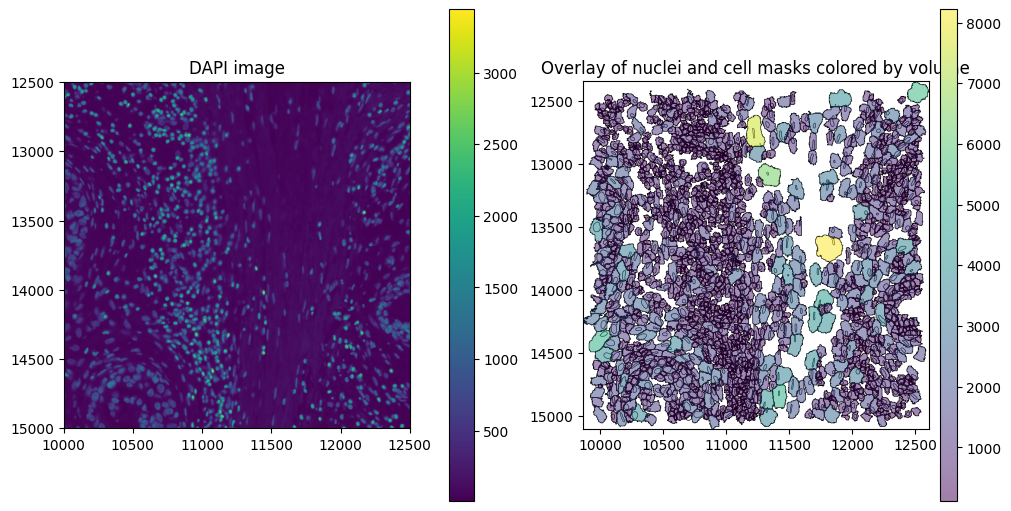

In [120]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot DAPI image
sdata_proseg2_crop.pl.render_images("morphology_focus").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot overlay of nuclei and cell boundaries colored by volume (proseg measures volume instead of area)
sdata_proseg2_crop.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="volume",
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.show(ax=axes[1], title="Overlay of nuclei and cell masks colored by volume", colorbar=True)

Finally, we can initialize the `SegTraQ` object, based on which all metrics can be computed.

In [129]:
st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2, 
    shapes_cell_id_key=None, 
    nucleus_shapes_cell_id_key=None, 
    tables_centroid_x_key = "centroid_x",
    tables_centroid_y_key = "centroid_y",
    points_background_id=2**32, #background ID used in Proseg,
    tables_area_volume_key="volume"
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [1, 2, 3, 4, 5]..., IDs in tables index: ['43284', '47755', '81603', '6654', '35126']...
  validate_spatialdata(


## Proseg 3

Proseg 3 already provides a `SpatialData` object as output, which can be read in easily.

In [136]:
sdata = sd.read_zarr(data_path / "proseg_output_v3/proseg-output.zarr")
sdata

/tmp/ipykernel_3768220/1107471245.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(data_path / "proseg_output_v3/proseg-output.zarr")


ValidationError: Cannot construct SpatialData object, input contains invalid elements.
For renaming, please see the discussion here https://github.com/scverse/spatialdata/discussions/707 .
To fix, run `spatialdata.utils.sanitize_table(adata)`.
  tables/table: `table.obs[region]` must be of type `categorical`, not `<class 'pandas.core.series.Series'>`.

Note that this object only contains one `cell_boundaries` layer in the shapes. To make full use of the 3D metrics of `SegTraQ`, we can also read in the segmentations at different z layers.

In [2]:
import gzip
import shutil
import warnings
from pathlib import Path

import geopandas as gpd

warnings.filterwarnings(
    "ignore",
    message="GeoSeries.notna.*previously returned False.*",
    category=UserWarning,
)


# adding the shapes for the different z layers
def decompress_geojson(gz_path: Path) -> Path:
    if gz_path.suffix == ".gz":
        json_path = gz_path.with_suffix("")  # strip .gz
        if not json_path.exists():
            with gzip.open(gz_path, "rt") as f_in, open(json_path, "w") as f_out:
                shutil.copyfileobj(f_in, f_out)
        return json_path
    return gz_path


path = Path("../../data/proseg_output_v3/")

# reading the polygons
polygons_gdf = gpd.read_file(decompress_geojson(path / "cell-polygons-layers.geojson.gz"))

# Polygon layers for multiple z stacks
for z in sorted(polygons_gdf["layer"].unique()):
    # select the current layer
    layer_gdf = polygons_gdf[polygons_gdf["layer"] == z]
    # filter out empty or missing geometries
    layer_gdf = layer_gdf[~layer_gdf.geometry.is_empty & layer_gdf.geometry.notna()]
    # putting everything into a spatialdata-compatible format
    layer_shapes = layer_gdf.set_index("cell")["geometry"].to_frame().copy()
    layer_shapes.index.name = "label_id"
    layer_shapes["cell_id"] = layer_shapes.index
    sdata.shapes[f"cell_boundaries_z{int(z)}"] = sd.models.ShapesModel.parse(layer_shapes)

sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (17956, 2) (2D shapes)
│     ├── 'cell_boundaries_z0': GeoDataFrame shape: (17638, 2) (2D shapes)
│     ├── 'cell_boundaries_z1': GeoDataFrame shape: (17823, 2) (2D shapes)
│     ├── 'cell_boundaries_z2': GeoDataFrame shape: (17822, 2) (2D shapes)
│     └── 'cell_boundaries_z3': GeoDataFrame shape: (16450, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17956, 5095)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_boundaries_z0 (Shapes), cell_boundaries_z1 (Shapes), cell_boundaries_z2 (Shapes), cell_boundaries_z3 (Shapes)
with the following elements not in the Zarr store:
    ▸ cell_boundaries_z2 (Shapes)
    ▸ cell_b

Some metrics in `SegTraQ` also depend on a nuclear segmentation mask. Here, we read in the nuclear segmentation provided by Xenium.

In [3]:
# adding nucleus boundaries from Xenium
import numpy as np
import pandas as pd
from shapely.geometry import MultiPolygon, Polygon
from shapely.validation import make_valid


# Convert a vertex table (one row per boundary vertex) into a GeoDataFrame of cell polygons.
def build_cell_polygons_from_vertices(
    df: pd.DataFrame,
    id_col: str = "label_id",
    x_col: str = "vertex_x",
    y_col: str = "vertex_y",
    keep_attrs=("cell_id",),
    drop_closed_duplicate: bool = True,
    fix_invalid: bool = True,
) -> gpd.GeoDataFrame:
    rows = []
    geometries = []

    for label_id, group in df.groupby(id_col, sort=False):
        xs = group[x_col].to_numpy()
        ys = group[y_col].to_numpy()

        # Drop last duplicate closing point if present
        if drop_closed_duplicate and len(xs) >= 2 and xs[0] == xs[-1] and ys[0] == ys[-1]:
            xs = xs[:-1]
            ys = ys[:-1]

        if len(xs) < 3:
            continue  # not enough points to form a polygon

        poly = Polygon(np.column_stack([xs, ys]))

        # Repair invalid polygons
        if fix_invalid and not poly.is_valid:
            poly = make_valid(poly)
            if poly.geom_type == "GeometryCollection":
                polys = [p for p in poly.geoms if p.geom_type in ("Polygon", "MultiPolygon")]
                if not polys:
                    continue
                poly = polys[0] if len(polys) == 1 else MultiPolygon(polys)

        if poly.is_empty:
            continue

        row = {id_col: int(label_id) if pd.notna(label_id) else None}
        for attr in keep_attrs:
            if attr in group.columns:
                row[attr] = group[attr].iloc[0]

        rows.append(row)
        geometries.append(poly)

    gdf = gpd.GeoDataFrame(rows, geometry=geometries)
    gdf.set_index(id_col, inplace=True)
    return gdf


nucleus_shapes = pd.read_parquet("../../data/nucleus_boundaries.parquet")
nucleus_shapes = build_cell_polygons_from_vertices(nucleus_shapes)
sdata.shapes["nucleus_boundaries"] = sd.models.ShapesModel.parse(nucleus_shapes)

# we also need to add the correct transformations to our new shapes
cell_shape_transformation = sd.transformations.get_transformation(sdata.shapes["cell_boundaries"])
sd.transformations.set_transformation(sdata.shapes["nucleus_boundaries"], cell_shape_transformation)

sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (17956, 2) (2D shapes)
│     ├── 'cell_boundaries_z0': GeoDataFrame shape: (17638, 2) (2D shapes)
│     ├── 'cell_boundaries_z1': GeoDataFrame shape: (17823, 2) (2D shapes)
│     ├── 'cell_boundaries_z2': GeoDataFrame shape: (17822, 2) (2D shapes)
│     ├── 'cell_boundaries_z3': GeoDataFrame shape: (16450, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (18608, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17956, 5095)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_boundaries_z0 (Shapes), cell_boundaries_z1 (Shapes), cell_boundaries_z2 (Shapes), cell_boundaries_z3 (Shapes), nucleus_boundaries (S

In [ ]:


segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_volume_key="volume",
    shapes_cell_id_key="cell",
    tables_cell_id_key="cell",
    images_key=None,
    tables_x_key="centroid_x",
    tables_y_key="centroid_y",
)